In [1]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
import torchvision
from matplotlib import offsetbox
import matplotlib.pyplot as plt
from nflows import flows, transforms, distributions
from nflows.transforms.normalization import ActNorm
from sklearn.preprocessing import MinMaxScaler
from tqdm import tqdm

from src.diffeomorphisms.image.nflow import NFlowImageDiffeomorphism
from src.inverse_problems.ambient_flow import AmbientFlowProblem
from src.manifolds.euclidean.image.pullback.standard import StandardPullbackImageEuclidean
from src.manifolds.euclidean.image.standard import StandardImageEuclidean
from src.riemannian_autoencoder.image.pullback.l2_tangent_space_pca import l2TangentSpacePCAPullbackImageRiemannianAutoencoder
from src.riemannian_autoencoder.image.pullback.standard import StandardPullbackImageRiemannianAutoencoder
from src.transforms.multi_layer_parity_conv2d.tanh import MultiLayerTanhParityConv2DTransform
from src.transforms.parity_conv import ParityConv2DTransform

device = "cuda" if torch.cuda.is_available() else "cpu"

# Set random seed for reproducibility
torch.manual_seed(31)

# Experiment settings
results_folder = os.path.join("results","mnist","tanh")
train_model = True

### Generate data ###

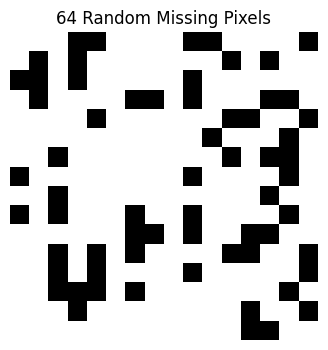

In [2]:
def create_exact_missing_mask(H, W, M):
    # Initialize all present (0s)
    mask = torch.ones(H * W, dtype=torch.bool)
    
    # Generate unique random indices
    indices = torch.randperm(H * W)[:M]
    
    # Set missing pixels
    mask[indices] = False
    
    return mask.view(H, W)

# Create mask
H, W = 16, 16
cor_level = 0.25
M = int(cor_level * H * W)

mask = create_exact_missing_mask(H, W, M)

plt.figure(figsize=(4,4))
plt.imshow(mask.cpu(), cmap='gray', interpolation='nearest')
plt.title(f'{M} Random Missing Pixels')
plt.axis('off')
plt.show()

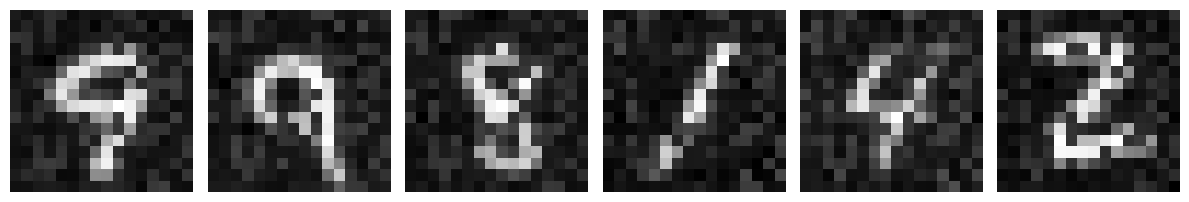

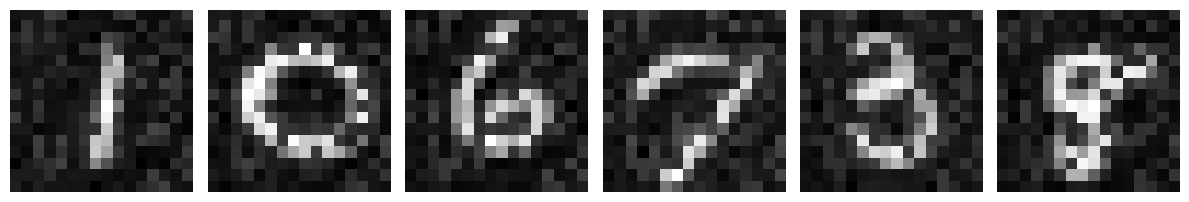

In [3]:
# Construct dataset
mnist_mean = 0.1307
mnist_var = 0.3081

# Define the transform
transform = torchvision.transforms.Compose([
    torchvision.transforms.Resize((H, W)),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((mnist_mean,), (mnist_var,))
])

# Load the full MNIST dataset
full_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)

# Calculate the split point (e.g., 80% for training, 20% for validation)
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size

# Create train and validation subsets
data_train_clean, data_val_clean = random_split(full_dataset, [train_size, val_size])

# add noise
noise_level = 0.1
data_train = [(img.clone().masked_fill(~mask, 0) + noise_level * torch.randn_like(img), label) 
              for img, label in data_train_clean]         
data_val = [(img.clone().masked_fill(~mask, 0) + noise_level * torch.randn_like(img), label) 
            for img, label in data_val_clean]

# Create the DataLoaders
batch_size = 64
train_loader = DataLoader(data_train, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(data_val, batch_size=batch_size, shuffle=False)

# Get a batch of examples from the training set
train_examples = next(iter(train_loader))
train_images, _ = train_examples
val_examples = next(iter(val_loader))
val_images, val_labels = val_examples

# Plot the first 6 images
fig, axes = plt.subplots(1, 6, figsize=(12, 8))
axes = axes.flatten()

for i in range(6):
    axes[i].imshow(train_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Plot the first 6 images
fig, axes = plt.subplots(1, 6, figsize=(12, 8))
axes = axes.flatten()

for i in range(6):
    axes[i].imshow(val_images[i].squeeze(), cmap='gray')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Learning Geometry ###

In [4]:
class MaskedForward(nn.Module):
    def __init__(self, mask):
        super().__init__()
        self.mask = mask
    
    def forward(self, x):
        return self.mask.to(x.device) * x

In [5]:
# Define the normalizing flow model
def create_flow_model(in_channels, height, width, kernel_size, latent_channels, order, n_flows, unit_det=False, parity_equivariance=False):
    base_dist = distributions.StandardNormal(shape=[in_channels, height, width])
    transforms_list = []
    for i in range(n_flows):
        transforms_list.append(ActNorm(features=in_channels))
        transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=i, unit_det=unit_det, parity_equivariance=parity_equivariance))
        transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=i+1, unit_det=unit_det, parity_equivariance=parity_equivariance))
        transforms_list.append(MultiLayerTanhParityConv2DTransform(in_channels, height, width, kernel_size, latent_channels, order=order, parity=i))
    transforms_list.append(ActNorm(features=in_channels))
    transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=n_flows, unit_det=unit_det, parity_equivariance=parity_equivariance))
    transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=n_flows+1, unit_det=unit_det, parity_equivariance=parity_equivariance))
    flow_transforms = transforms.CompositeTransform(transforms_list)
    return flows.Flow(transform=flow_transforms, distribution=base_dist)

In [6]:
# Define the conditional normalizing flow model
def create_conditional_flow_model(in_channels, height, width, kernel_size, latent_channels, order, n_flows, unit_det=False, parity_equivariance=False):
    context_encoder = nn.Sequential(
            nn.Conv2d(in_channels, 64, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 2*in_channels, 3, padding=1)
        )
    base_dist = distributions.ConditionalDiagonalNormal(shape=[in_channels, height, width], context_encoder=context_encoder)
    transforms_list = []
    for i in range(n_flows):
        transforms_list.append(ActNorm(features=in_channels))
        transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=i, unit_det=unit_det, parity_equivariance=parity_equivariance))
        transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=i+1, unit_det=unit_det, parity_equivariance=parity_equivariance))
        transforms_list.append(MultiLayerTanhParityConv2DTransform(in_channels, height, width, kernel_size, latent_channels, order=order, parity=i))
    transforms_list.append(ActNorm(features=in_channels))
    transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=n_flows, unit_det=unit_det, parity_equivariance=parity_equivariance))
    transforms_list.append(ParityConv2DTransform(in_channels, height, width, kernel_size, parity=n_flows+1, unit_det=unit_det, parity_equivariance=parity_equivariance))
    flow_transforms = transforms.CompositeTransform(transforms_list)
    return flows.Flow(transform=flow_transforms, distribution=base_dist)


In [7]:
# Initialize the model
forward = MaskedForward(mask)

L = 64
K = 5
order = 6
n_flows = 6
prior_flow = create_flow_model(1, H, W, K, L, order, n_flows)
prior_diffeo = NFlowImageDiffeomorphism(1, H, W, prior_flow)

posterior_flow = create_conditional_flow_model(1, H, W, K, L, order, n_flows)
posterior_diffeo = NFlowImageDiffeomorphism(1, H, W, prior_flow)

reg_param=0.1
model = AmbientFlowProblem(forward, prior_diffeo, posterior_diffeo, noise_level, reg_param=reg_param).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [8]:
# Training loop
def train(model, train_loader, optimizer, n_epochs, save_dir='results', start_epoch=0, real_data_reg=None):
    best_loss = float('inf')
    os.makedirs(save_dir, exist_ok=True)

    for epoch in range(start_epoch, n_epochs):
        epoch_loss = 0
        for y, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs}"):
            optimizer.zero_grad()
            
            # Compute loss
            loss = model.reconstruction_loss(y.to(device))

            if real_data_reg is not None:
                log_p_theta_gt = model.phi.nflow.log_prob(data_train_clean[0:64].to(device))
                loss -= real_data_reg * log_p_theta_gt.mean()

            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
        
        # Calculate average loss for the epoch
        avg_epoch_loss = epoch_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{n_epochs}, Average Loss: {avg_epoch_loss:.4f}")

        # Save checkpoint
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': loss,
            'best_loss': best_loss,
        }
        
        if (epoch + 1) % 5 == 0:
            torch.save(checkpoint, os.path.join(save_dir, f'epoch_{epoch+1}_model.pth'))

        if avg_epoch_loss < best_loss:
            best_loss = avg_epoch_loss
            torch.save(checkpoint, os.path.join(save_dir, 'best_model.pth'))

    print("Training completed. Best model saved with loss:", best_loss)

In [9]:
# Train the model
n_epochs = 100
checkpoint_dir = os.path.join(results_folder, f"checkpoints_latent_dim={L}_kernel_size={K}_order={order}_n_flows={n_flows}")

# Train or load model
if train_model:
    start_epoch = 0
    best_loss = float('inf')

    # Check if there's a checkpoint to resume from
    latest_checkpoint = max(glob.glob(os.path.join(checkpoint_dir, 'epoch_*_model.pth')), default=None, key=os.path.getctime)
    
    if latest_checkpoint:
        print(f"Resuming training from {latest_checkpoint}")
        checkpoint = torch.load(latest_checkpoint)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_loss = checkpoint['best_loss']

    train(model, train_loader, optimizer, n_epochs, save_dir=checkpoint_dir, start_epoch=start_epoch)
else:
    # best_model_path = os.path.join(checkpoint_dir, 'epoch_200_model.pth')
    best_model_path = os.path.join(checkpoint_dir, 'best_model.pth')
    checkpoint = torch.load(best_model_path)
    model.load_state_dict(checkpoint['model_state_dict'])

# Set the model to evaluation mode
model.eval()

Epoch 1/100: 100%|██████████| 750/750 [22:54<00:00,  1.83s/it]


Epoch 1/100, Average Loss: 9328.3865


Epoch 2/100: 100%|██████████| 750/750 [22:55<00:00,  1.83s/it]


Epoch 2/100, Average Loss: 4070.3289


Epoch 3/100: 100%|██████████| 750/750 [22:56<00:00,  1.84s/it]


...

Epoch 4/100, Average Loss: 3727.3143


Epoch 5/100: 100%|██████████| 750/750 [22:57<00:00,  1.84s/it]


Epoch 5/100, Average Loss: 3678.3224


Epoch 6/100:   0%|          | 3/750 [00:06<25:21,  2.04s/it]


KeyboardInterrupt: 

In [10]:
# Generate samples
@torch.no_grad()
def generate_samples(model, n_samples):
    samples = model.sample(n_samples).cpu()
    return samples

In [11]:
# Generate conditional samples
@torch.no_grad()
def generate_samples_with_context(model, n_samples, context):
    samples = model.sample(n_samples, context=context[None]).squeeze().cpu()
    return samples

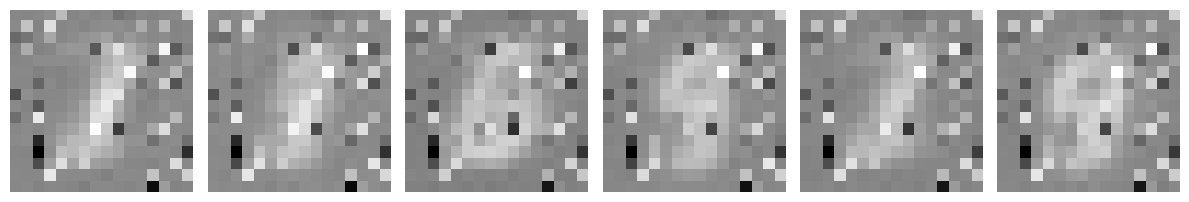

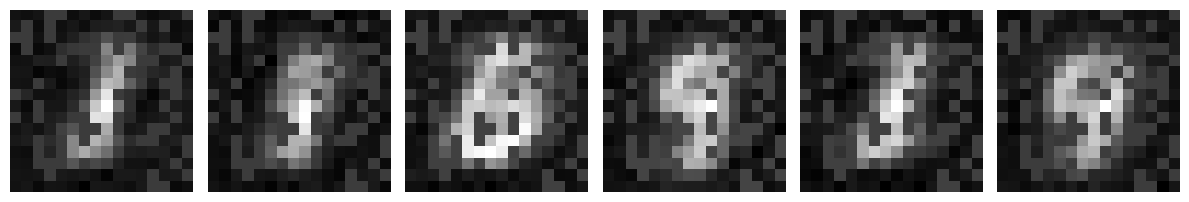

In [12]:
# Visualize generated samples
prior_samples = generate_samples(model.phi.nflow, 100).reshape(-1,H,W)
cor_prior_samples = forward(prior_samples)

# Plot the first 6 images
fig, axes = plt.subplots(1, 6, figsize=(12, 8))
axes = axes.flatten()
for i in range(6):
    axes[i].imshow(prior_samples[i].squeeze(), cmap='gray')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

# Plot the first 6 images
fig, axes = plt.subplots(1, 6, figsize=(12, 8))
axes = axes.flatten()
for i in range(6):
    axes[i].imshow(cor_prior_samples[i].squeeze(), cmap='gray')
    axes[i].axis('off')
plt.tight_layout()
plt.show()

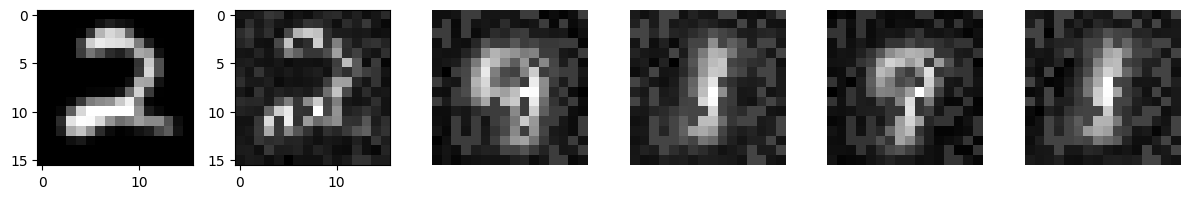

In [19]:
# Visualize generated samples
data_idx = 8
posterior_samples = generate_samples_with_context(model.phy.nflow, 5, data_train[data_idx][0].to(device))
cor_posterior_samples = forward(posterior_samples)

# Plot the images
fig, axes = plt.subplots(1, 6, figsize=(12, 8))
axes = axes.flatten()
axes[0].imshow(data_train_clean[data_idx][0].squeeze(), cmap='gray')
plt.tight_layout()
axes[1].imshow(data_train[data_idx][0].squeeze(), cmap='gray')
plt.tight_layout()
for i in range(4):
    axes[i+2].imshow(cor_posterior_samples[i].squeeze(), cmap='gray')
    axes[i+2].axis('off')
plt.tight_layout()
plt.show()

### Evaluating Geometry ###

In [14]:
# Construct reference manifold
euclidean = StandardImageEuclidean(1, H, W)

# Construct pullback manifold
manifold = StandardPullbackImageEuclidean(model.phi)

In [ ]:
# Compute reconstructions of the training data points
rec_data_train = torch.zeros(100, 1, H, W)
# rec_data_train = torch.zeros(len(data_train), 1, H, W)
for i, xy in enumerate(data_train): # TODO use the encoder network to predict the mean and use that rather than sampling...
    context = xy[0]
    samples = generate_samples_with_context(model.phy.nflow, 10, context.to(device))
    rec_data_train[i] = samples.mean(0)
    if i == 99:
        break

In [16]:
# Compute geodesics
# Define the dimensions
num_points = num_geodesics = 16

ref_geodesics = torch.zeros(num_geodesics, num_points, 1, H, W)
phi_geodesics = torch.zeros(num_geodesics, num_points, 1, H, W)

# Create x0 and x1 tensors
x0 = rec_data_train[0:2*num_geodesics:2].to(device)
x1 = rec_data_train[1:2*num_geodesics+1:2].to(device)

# Create a grid of points
t = torch.linspace(0., 1., num_points).to(device)

# Generate geodesics
for i in range(num_geodesics):
    ref_geodesics[i] = euclidean.geodesic(x0[i], x1[i], t).detach().cpu()
    phi_geodesics[i] = manifold.geodesic(x0[i], x1[i], t).detach().cpu()

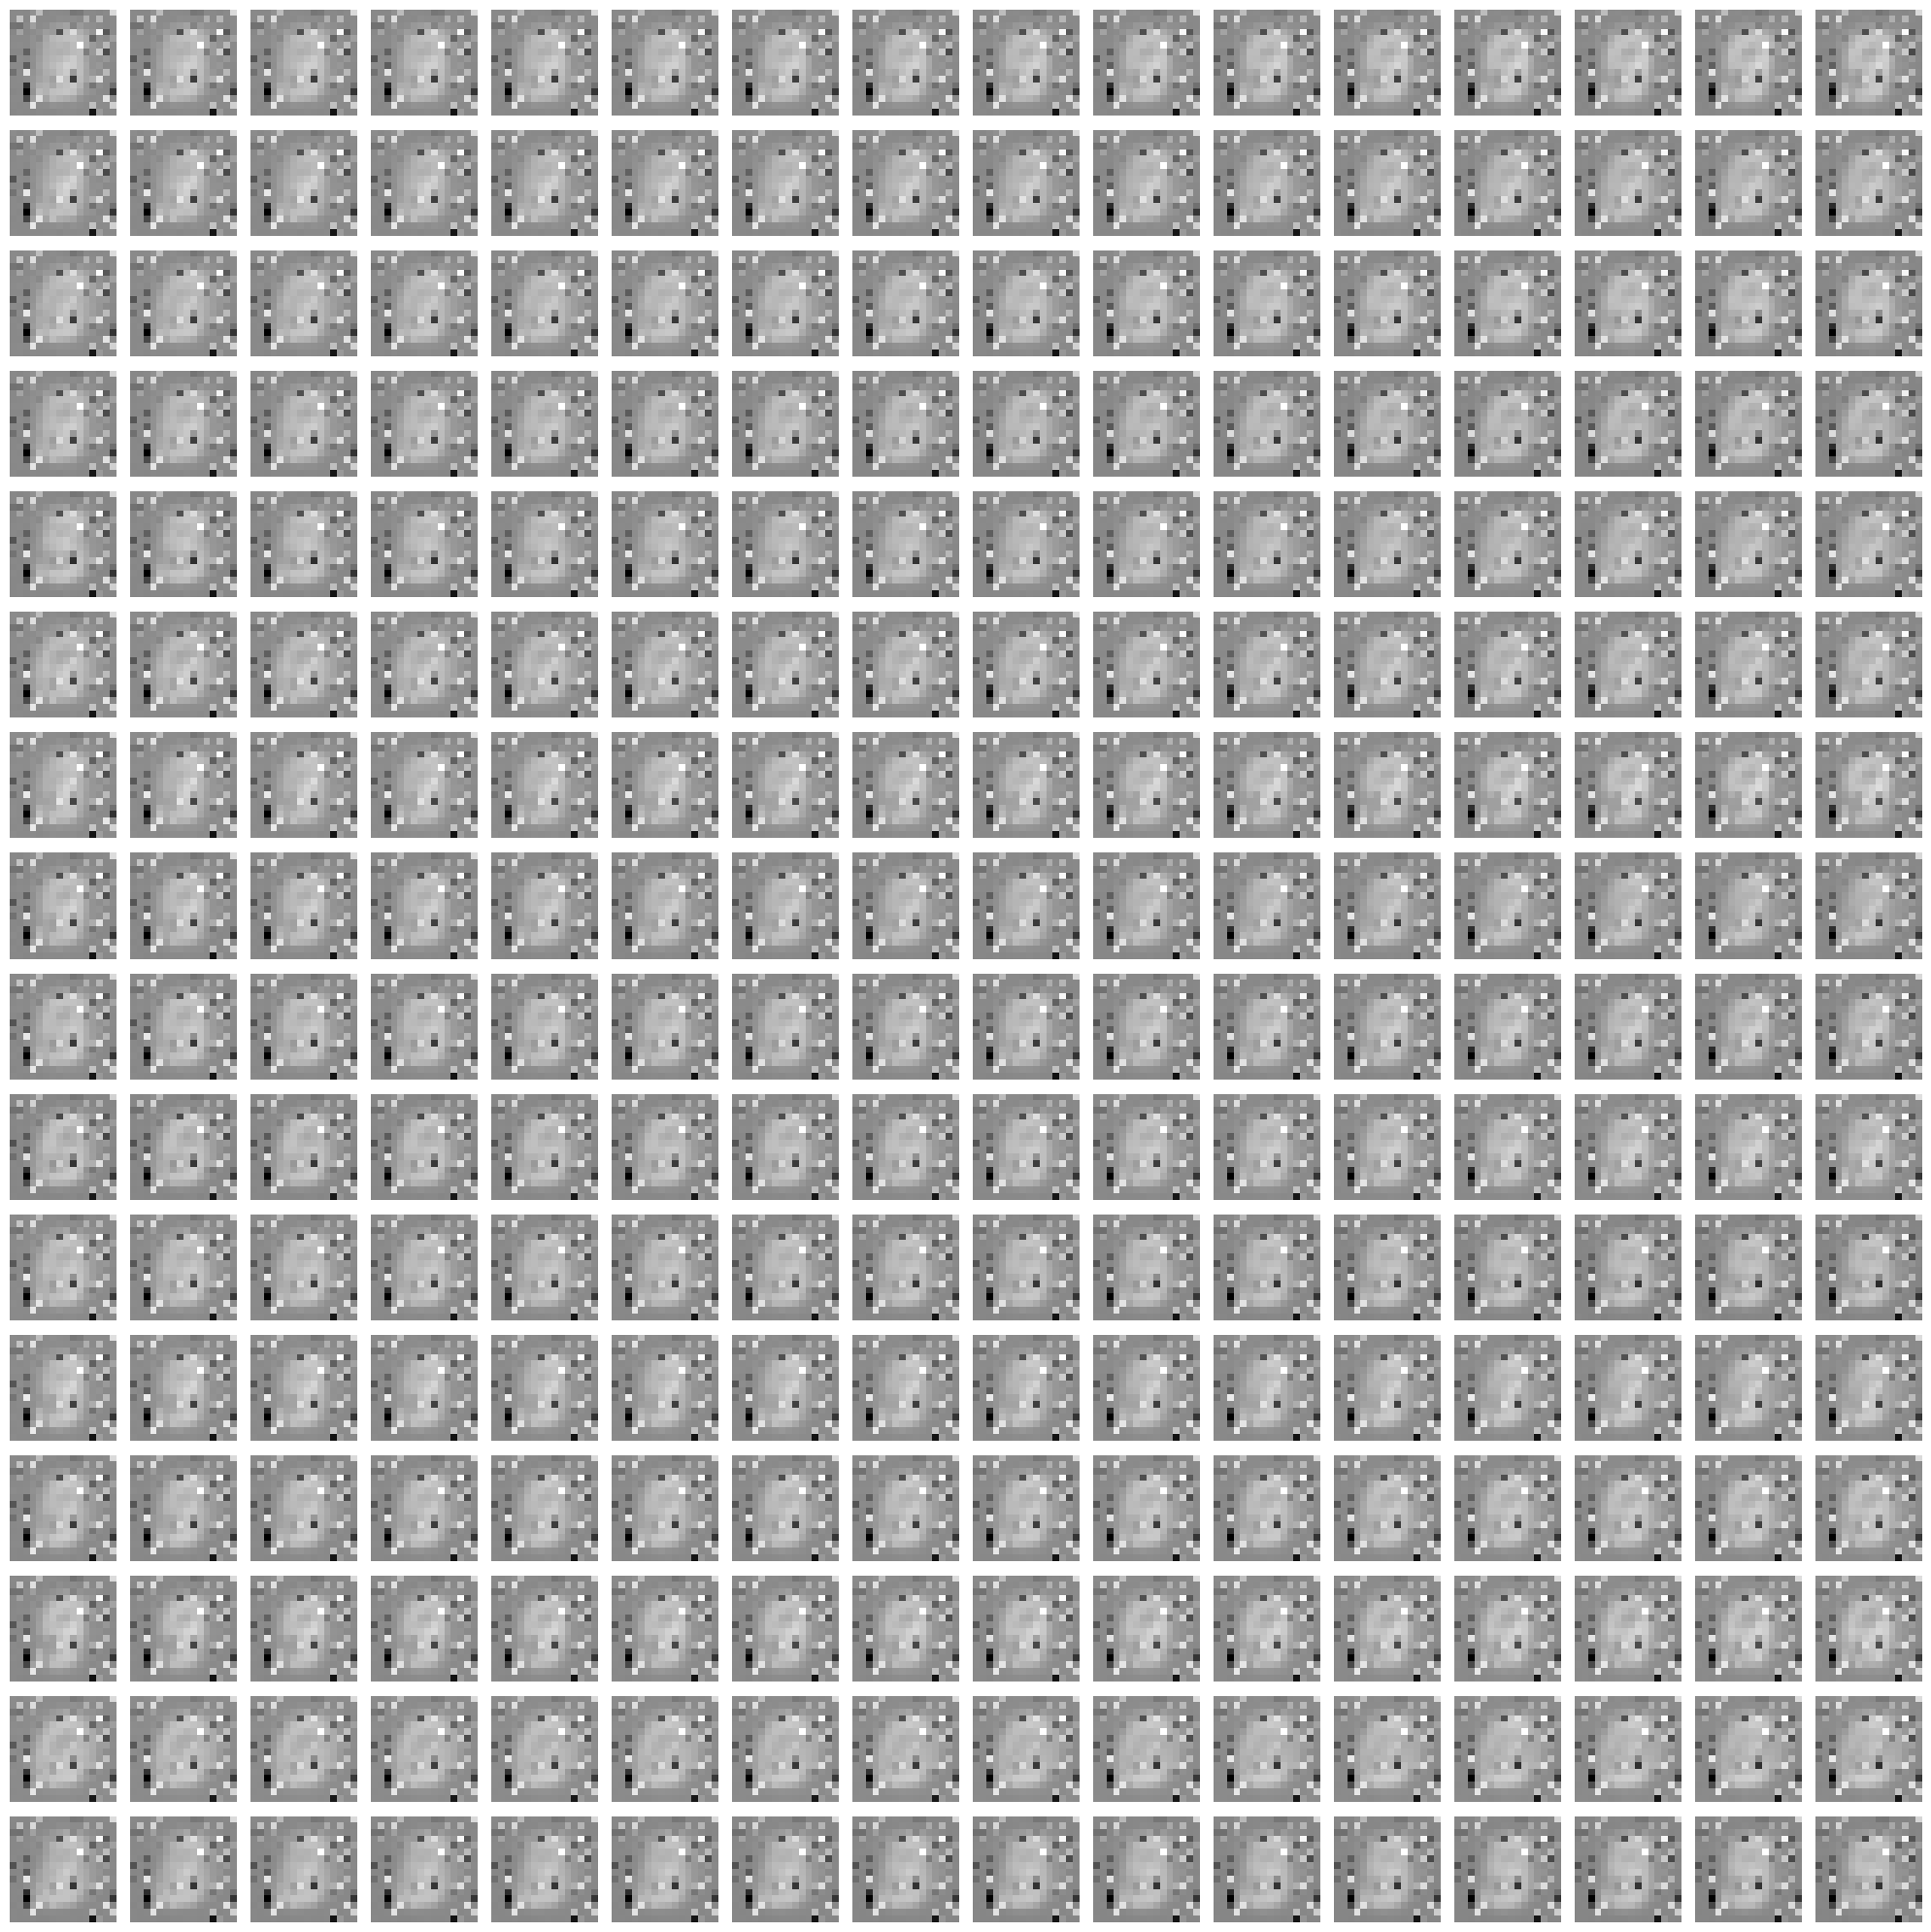

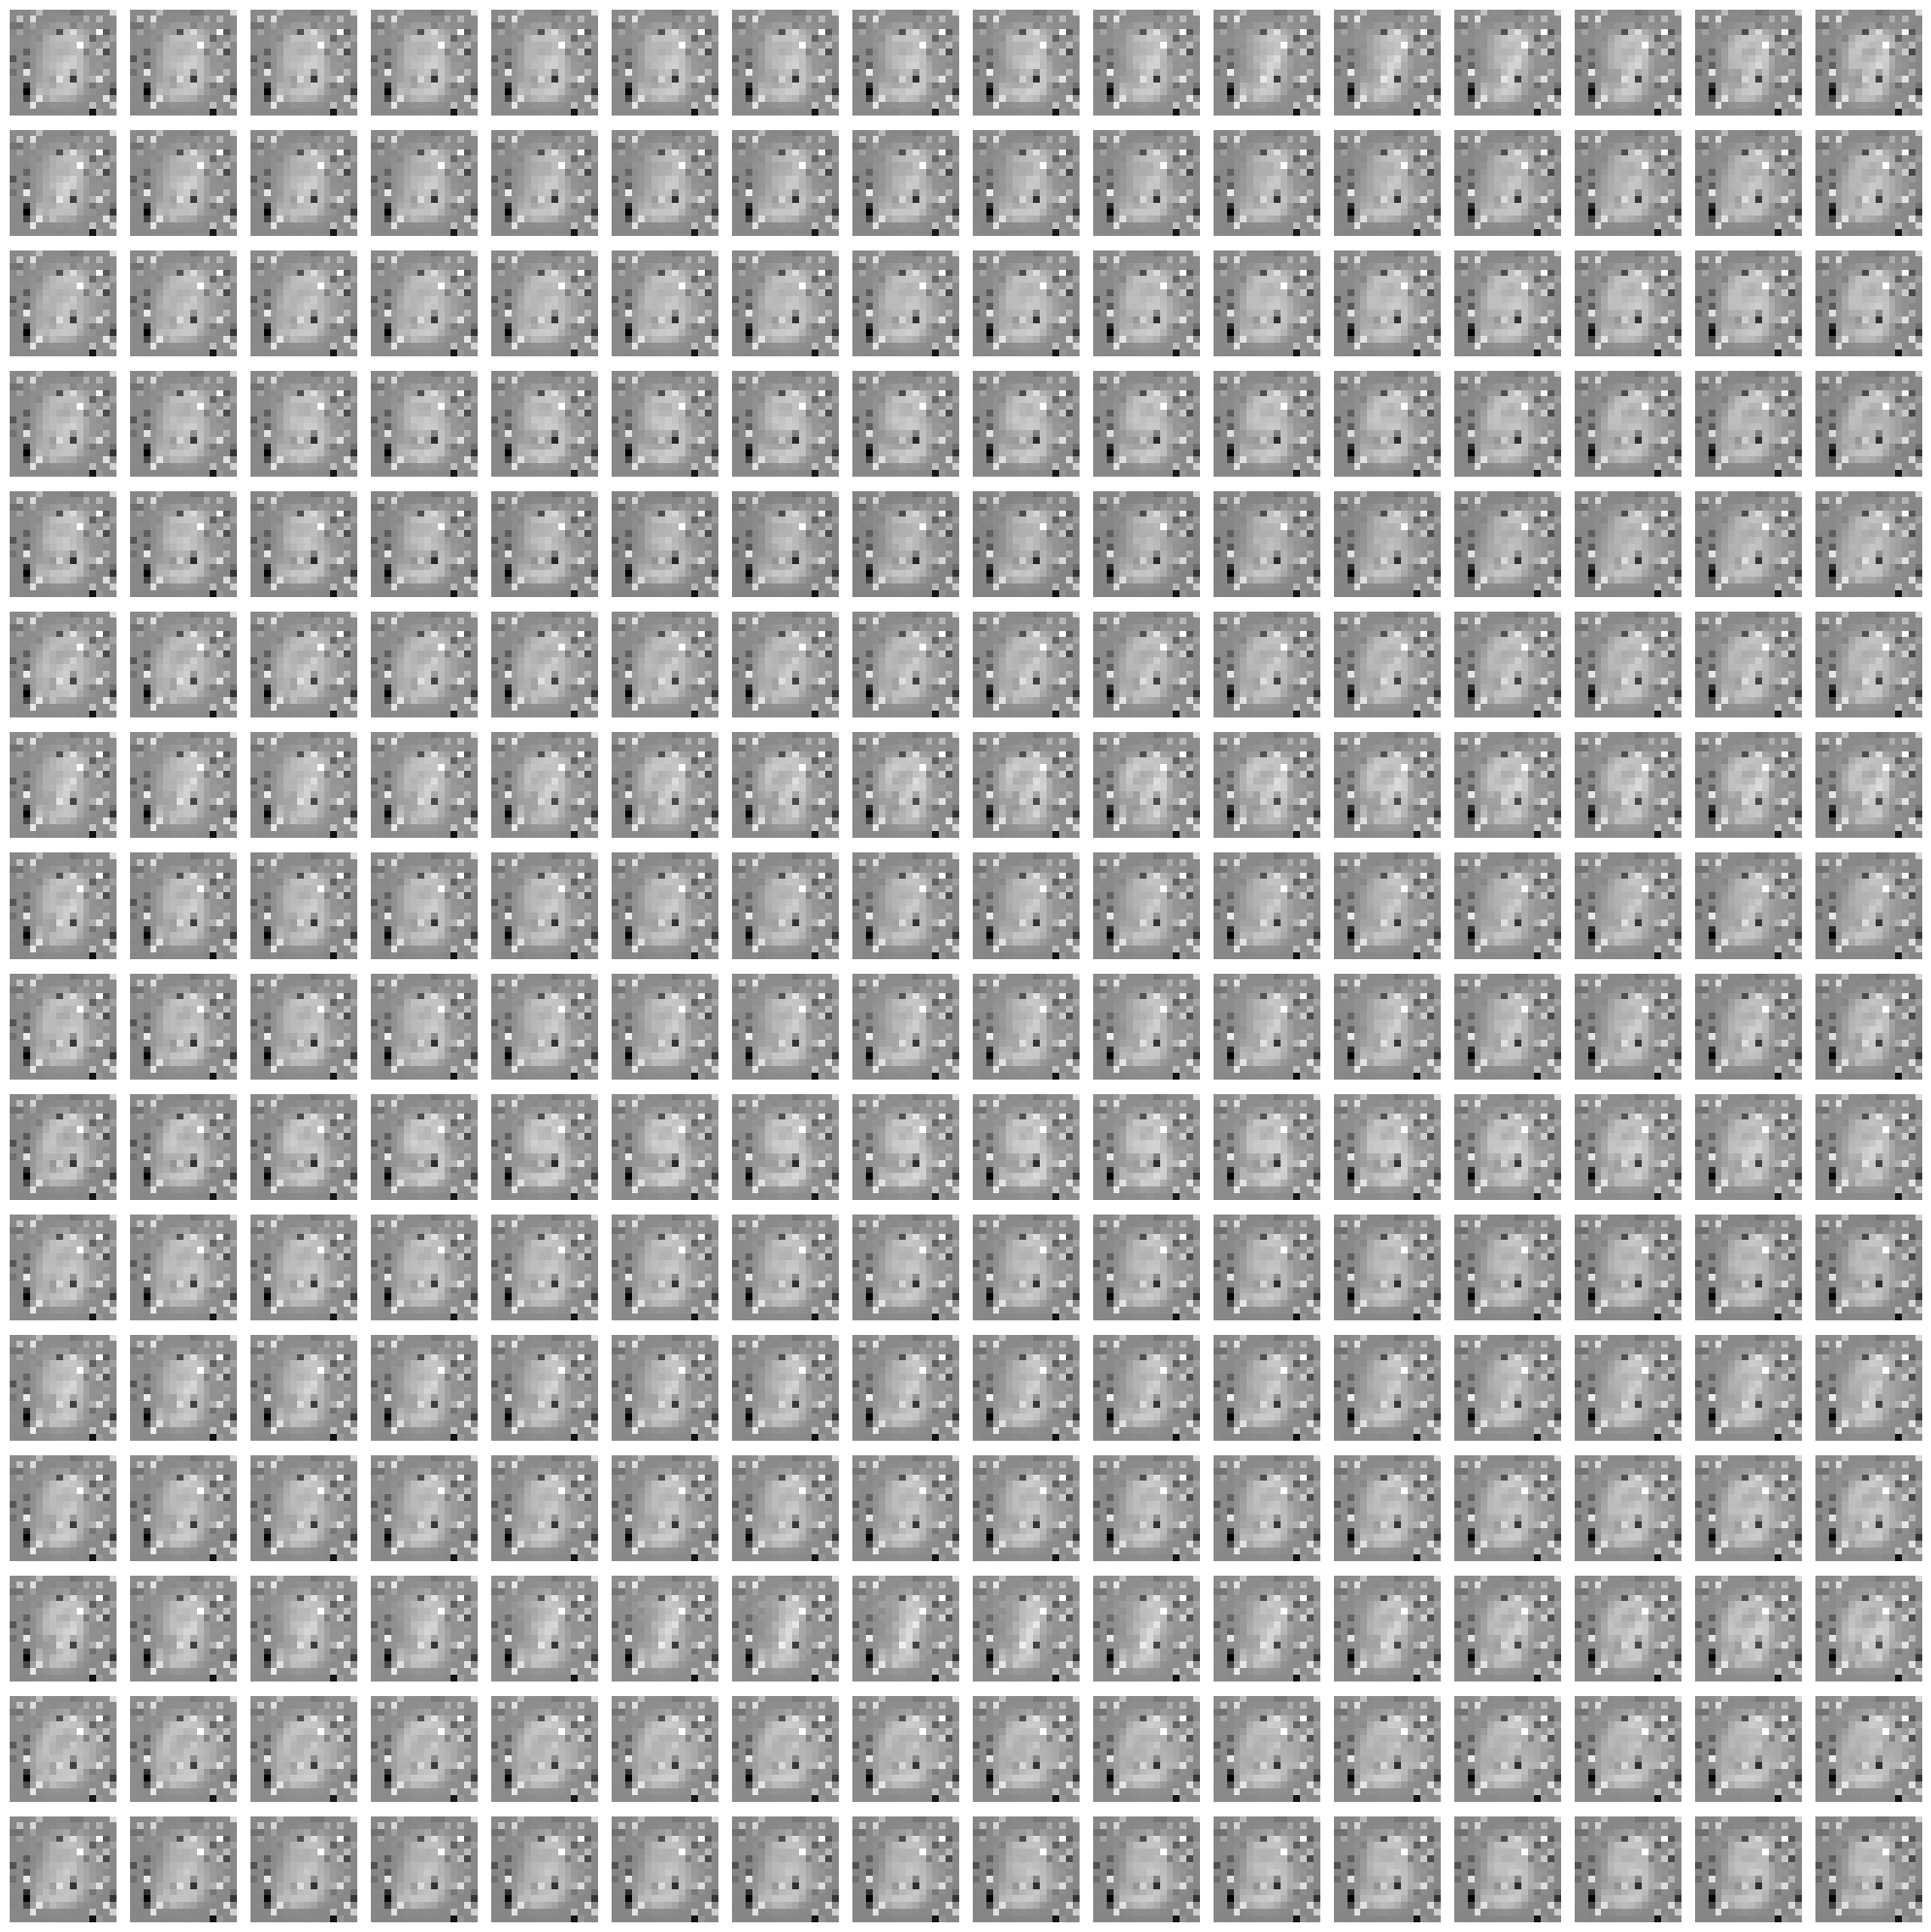

In [17]:
# Create a 16x16 grid of subplots
fig, axes = plt.subplots(num_geodesics, num_points, figsize=(20, 20))

# Plot each image in the grid
for i in range(num_geodesics):
    for j in range(num_points):
        axes[i, j].imshow(ref_geodesics[i, j].squeeze(), cmap='gray')
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

# Create a 16x16 grid of subplots
fig, axes = plt.subplots(num_geodesics, num_points, figsize=(20, 20))

# Plot each image in the grid
for i in range(num_geodesics):
    for j in range(num_points):
        axes[i, j].imshow(phi_geodesics[i, j].squeeze(), cmap='gray')
        axes[i, j].axis('off')

plt.tight_layout()
plt.show()

In [18]:
# Construct RAE
epsilon = 0.1
rae = StandardPullbackImageRiemannianAutoencoder(manifold, epsilon=epsilon, device=device)
d_eps = rae.d_eps

l2_tpca_rae = l2TangentSpacePCAPullbackImageRiemannianAutoencoder(manifold, rec_data_train[0:100].to(device), d_eps)

constructed a Riemannian autoencoder with d_eps = 2 and effectice eps = 0.011556025594472885
constructed a Riemannian autoencoder with latent dimension = 2 and effectice eps = 0.7299311757087708


### Reconstructing the data ###